# Hand Pose Mini-Project

## Stage 1: Preprocessing Pipeline

Demonstrates the current preprocessing pipeline used in the mini-project.

The pipeline includes:
1. Loading images from disk
2. Converting to grayscale
3. Resizing to 128x128
4. Normalizing pixel values to range [0, 1]

In [13]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [14]:
from model_free.io_utils import list_images, load_image
from model_free.preprocessing import preprocess_image

### Step (1): Loading images from disk

In [15]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "processed"

images = list_images(DATA_DIR)
sample_images = images[:3]

print(f"Found {len(images)} images in dataset")
print("Sample images:")
for img in sample_images:
    print(" -", img.name)

Found 396 images in dataset
Sample images:
 - img_001.jpg
 - img_002.jpg
 - img_003.jpg


### Steps (2,3,4): Grayscale, Resizing, Normalizing

Image: img_001.jpg
Processed shape: (128, 128)
Min value: 0.0745
Max value: 0.9647


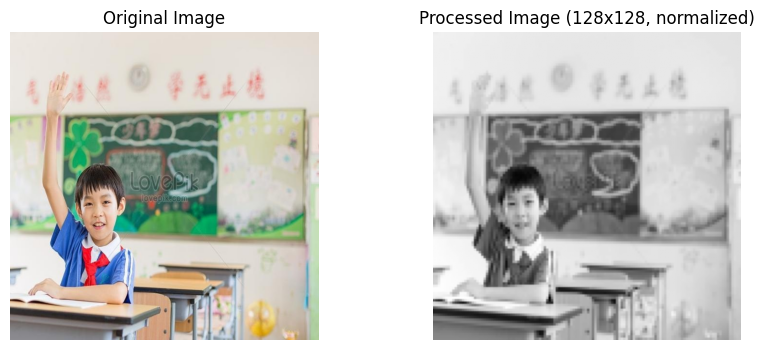

In [16]:
import numpy as np

def show_pipeline_example(image_path):
    original = load_image(image_path)
    processed = preprocess_image(image_path)

    plt.figure(figsize=(10,4))

    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original[..., ::-1])
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Processed Image (128x128, normalized)")
    plt.imshow(processed, cmap="gray")
    plt.axis("off")

    print(f"Image: {image_path.name}")
    print(f"Processed shape: {processed.shape}")
    print(f"Min value: {processed.min():.4f}")
    print(f"Max value: {processed.max():.4f}")

show_pipeline_example(sample_images[0])


## Stage 2: Convolution Kernel Layer

### Demonstrates the effect of individual convolution kernels on the preprocessed image.

The pipeline includes:

1. Taking the preprocessed image (128x128, normalized)
2. Applying selected convolution kernels
3. Visualizing the resulting feature maps

Kernel used: sobel_vertical
Feature map shape: (128, 128)
Min value: -3.8235
Max value: 3.5647


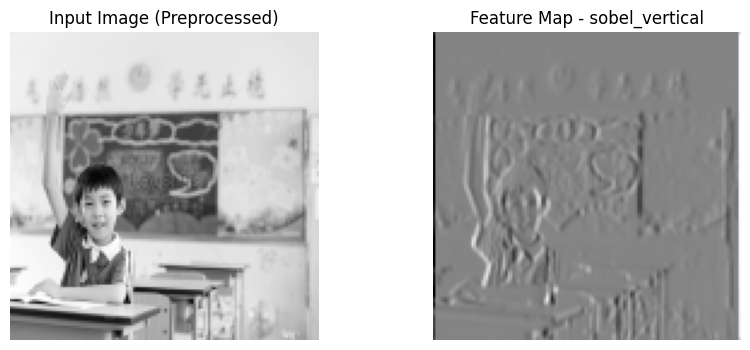

In [17]:
from model_free.conv_layer import apply_convolution, list_kernel_names, get_kernel

def show_single_kernel_effect(image_path, kernel_name):
    processed = preprocess_image(image_path)
    kernel = get_kernel(kernel_name)
    feature_map = apply_convolution(processed, kernel)

    plt.figure(figsize=(10,4))

    plt.subplot(1, 2, 1)
    plt.title("Input Image (Preprocessed)")
    plt.imshow(processed, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Feature Map - {kernel_name}")
    plt.imshow(feature_map, cmap="gray")
    plt.axis("off")

    print(f"Kernel used: {kernel_name}")
    print(f"Feature map shape: {feature_map.shape}")
    print(f"Min value: {feature_map.min():.4f}")
    print(f"Max value: {feature_map.max():.4f}")


# Example demonstration
show_single_kernel_effect(sample_images[0], "sobel_vertical")


## Stage 3: Multiple Kernels Pipeline Demonstration

### Demonstrates the full convolution pipeline:

1. optional smoothing
2. multiple kernels
3. ReLU
4. max pooling

And shows all resulting feature maps together.

Applied kernels: ['sobel_vertical', 'sobel_horizontal', 'laplacian']
Stacked output shape: (3, 64, 64)
Format: (n_kernels, H, W)


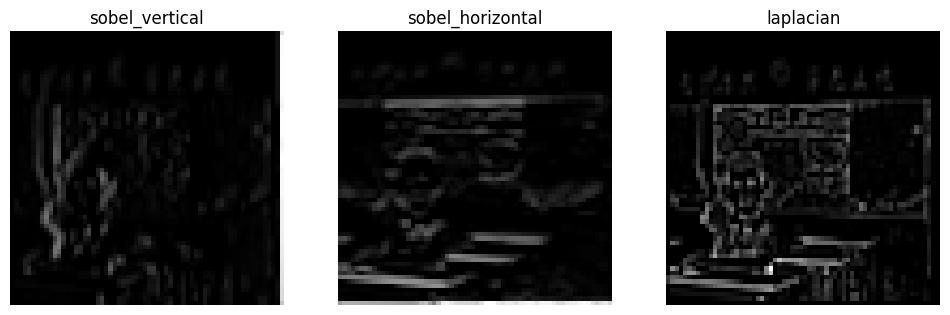

In [18]:
from model_free.conv_layer import process_image_with_kernels, DEFAULT_IMPORTANT_KERNELS

def show_multiple_kernels_effect(image_path):
    processed = preprocess_image(image_path)
    stacked_maps = process_image_with_kernels(processed)

    n_kernels = stacked_maps.shape[0]

    plt.figure(figsize=(12, 4))
    for i in range(n_kernels):
        plt.subplot(1, n_kernels, i + 1)
        plt.title(DEFAULT_IMPORTANT_KERNELS[i])
        plt.imshow(stacked_maps[i], cmap="gray")
        plt.axis("off")

    print("Applied kernels:", DEFAULT_IMPORTANT_KERNELS)
    print(f"Stacked output shape: {stacked_maps.shape}")
    print("Format: (n_kernels, H, W)")


# Example demonstration
show_multiple_kernels_effect(sample_images[0])